In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [18]:
class Value:
    def __init__(self, data, _children= (), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out
    
    def __sub__(self, other):
        out = (self.data - other.data, (self, other), '-')
        return out
                
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), "*")
        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2 * x) - 1) / (math.exp(2 * x) + 1)
        out = Value(t, (self, ), 'tanh')
        return out
    
    
    

In [19]:
v1 = Value(51.0, label= 'v1')
v2 = Value(100.0, label= 'v2')
v2 - v1

(49.0, (Value(data=100.0), Value(data=51.0)), '-')

In [4]:
a = Value(2.0, label= 'a')
b = Value(-3.0, label= 'b')
c = Value(10, label= 'c')
e = a * b; e.label= 'e'
d = e + c; d.label = 'd'
f = Value(-2, label= 'f')
L = d * f; L.label = "L"
L



Value(data=-8.0)

In [5]:
#Delete it from system later
from graphviz import Digraph
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot= Digraph(format= 'svg', graph_attr={'rankdir' : 'LR'}) 

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name= uid, label= '{%s | data % 4f | grad %.4f}' % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name= uid + n._op, label= n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge((str(id(n1))), str(id(n2))+ n2._op)

    return dot

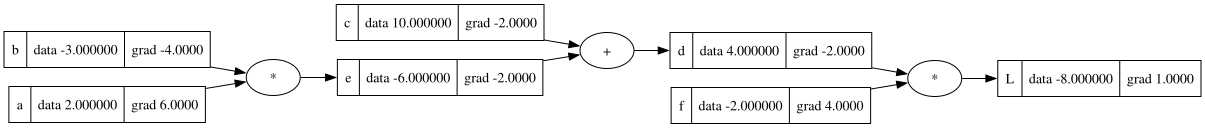

In [69]:
draw_dot(L)

In [ ]:
L.grad = 1
d.grad = f.data #-2.0
f.grad = d.data #4.0
e.grad = f.data #-2.0
c.grad = f.data # -2.0
a.grad = 6.0
b.grad = -4.0

#Derivative Calculations;
h = 0.0000001

1. Derivative of L with respect to L = 1.0 {obviously}

2. Derivative of L with respect to d = f
    L = d * f
    L = (d + h) * f

    [f(x + h) - f(x)] / h

    [f*(d + h) - f*(d)] / h
    fd + fh - fd / h
    fh / h
    f

3. Derivative of L with respect to f = d

    L = d * f
    L = d * (f+h)

    f(x + h) - f(x) / h

    d*(f + h) - d(f) / h
    df + dh - df / h
    dh / h
    d

#Chain rule: If variable x depends on variable y and y in turn depends on z, then x is related to z by:
    dz / dx = [dz / dy  *  dx / dz]

4. derivative of L with respect to e
    dL/de = dd/de * dL/dd
            1.0 * -2.0 = -2.0

    dd/de:
        d = e + c

        #Derivative of d with respect to e
        d = (e + h) + c

        f(x + h) - f(x) / h
        e + h + c - e - c /h
        h / h
        1.0     ..Fun fact: If e or c are tweaked by any value, the result would grow up by that particual value of the tweak!
5. derivative of L with respect to c
    dL/dc = dd/dc * dL/dd
            1.0 * -2.0 = -2.0

    #DERIVATIVE of d with respect to c
        d = e + c
        d = e + (c + h)

        f(x + h) - f(x) / h
        e + c + h - e + c / h
        h / h
        1.0     ..Fun fact: If e or c are tweaked by any value, the result would grow up by that particual value of the tweak!

6. Derivative of L with respect to a
    dL/da = de/da * dL/de
            -3.0 * -2.0 = 6.0

        #derivative of e with respect to a
        e = a * b
        e = (a + h) * b

        f(x + h) - f(x) / h
        b*(a + h) - b*(a) / h
        ba + bh - ba / h
        bh / h
        b  #-3.0

7. Derivative of L with respect to b
    dL/db = de/db * dL/de 
            2.0 * -2.0 = -4.0       

    #derivative of e with respect to b
    e = a * b
    e = a * (b + h)

    f(x + h) - f(x) / h
    a*(b + h) - a*(b) / h
    ab + ah - ab / h
    ah / h
    a # 2.0




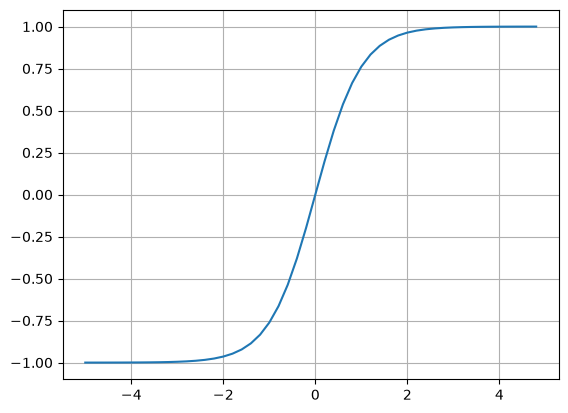

In [10]:
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2))); plt.grid();

In [ ]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

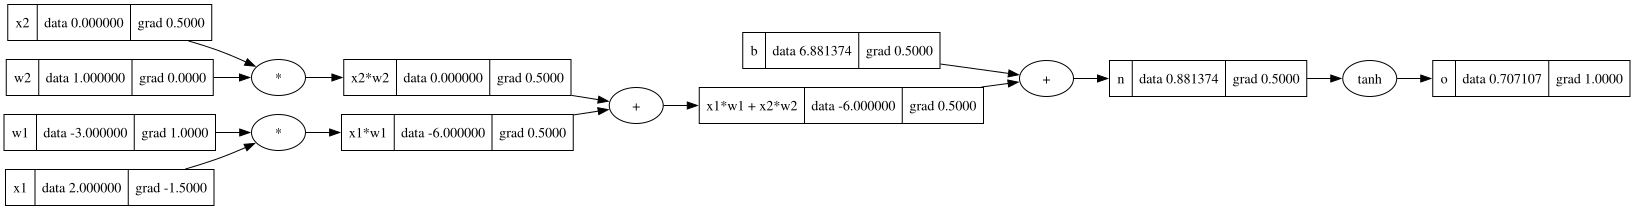

In [83]:
draw_dot(o)

In [82]:
o.grad = 1.0
n.grad = 1 - o.data ** 2 # 0.5
'''
o = tanh(n)
do/dn = 1 - tanh(n) ** 2 => 1 - o**2
'''
x1w1x2w2.grad = 0.5
b.grad = 0.5
x1w1.grad = 0.5
x2w2.grad = 0.5

x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad



In [65]:
1 - o.data ** 2

0.4999999999999999